In [6]:
# Packages used
import pandas_datareader.data as web
import math
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
import scipy as sp
from scipy import stats
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

In [7]:
# Collection of data from French FAMA
startdate="2015-01-01"
enddate="2019-12-31";
# Fetch Fama-French 3 Factors (monthly, U.S.)
ff3 = web.DataReader("F-F_Research_Data_Factors", "famafrench",start=startdate,end=enddate) # F_F_Research_Data_Factors is for monthly returns
# ff3 is a dictionary of tables, table[0] = factor returns
factors = ff3[0]

C:\Users\abhis\AppData\Local\Temp\ipykernel_18180\3950343988.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff3 = web.DataReader("F-F_Research_Data_Factors", "famafrench",start=startdate,end=enddate) # F_F_Research_Data_Factors is for monthly returns
C:\Users\abhis\AppData\Local\Temp\ipykernel_18180\3950343988.py:5: FutureWarning: The argument 'date_parser' is deprecated and will be removed in a future version. Please use 'date_format' instead, or read your data in as 'object' dtype and then call 'to_datetime'.
  ff3 = web.DataReader("F-F_Research_Data_Factors", "famafrench",start=startdate,end=enddate) # F_F_Research_Data_Factors is for monthly returns


In [8]:
#Collecting Ticker data from yahoo finance!
TICKER=yf.Ticker("GS"); # Random stock
stockdata=TICKER.history(start=startdate,end=enddate,interval='1d'); 
# Avoiding the year 2024 due to payment of dividends. Here the computation of return isn't that simple.
stockdata["month-year"]=stockdata.index.strftime("%Y-%m")
stockdata["month-year"]=stockdata["month-year"].astype(str)

In [9]:
""" 
Need to compute the monthly stock returns. 
The formula is given by 1+ R_{monthly} = \prod_{t in a month} (1+ R_t} = closing_{last date of month}/closing_{first date of the month}"""
print(factors.info())
DATES=set(factors.index)
stockdata=stockdata[["Close","month-year"]]
print(len(DATES));
for j in DATES:
    k=j.to_timestamp().strftime("%Y-%m")
    newdata=stockdata[stockdata["month-year"]==k]
    val=(newdata.iloc[-1,0]/newdata.iloc[0,0])-1;
    factors.loc[j,"Stock-RF"] = (((newdata.iloc[-1,0]/newdata.iloc[0,0])-1) - (factors.loc[j,"RF"]/100))*100
# All mmy data is in percentage, so need to convert it to percentage accordingly :-(

<>:3: SyntaxWarning: invalid escape sequence '\p'
<>:3: SyntaxWarning: invalid escape sequence '\p'
C:\Users\abhis\AppData\Local\Temp\ipykernel_18180\1485230225.py:3: SyntaxWarning: invalid escape sequence '\p'
  The formula is given by 1+ R_{monthly} = \prod_{t in a month} (1+ R_t} = closing_{last date of month}/closing_{first date of the month}"""


<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 60 entries, 2015-01 to 2019-12
Freq: M
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Mkt-RF  60 non-null     float64
 1   SMB     60 non-null     float64
 2   HML     60 non-null     float64
 3   RF      60 non-null     float64
dtypes: float64(4)
memory usage: 2.3 KB
None
60


                            OLS Regression Results                            
Dep. Variable:               Stock-RF   R-squared:                       0.396
Model:                            OLS   Adj. R-squared:                  0.385
Method:                 Least Squares   F-statistic:                     37.97
Date:                Sun, 02 Nov 2025   Prob (F-statistic):           7.36e-08
Time:                        19:27:47   Log-Likelihood:                -186.00
No. Observations:                  60   AIC:                             376.0
Df Residuals:                      58   BIC:                             380.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.9245      0.727     -1.271      0.2

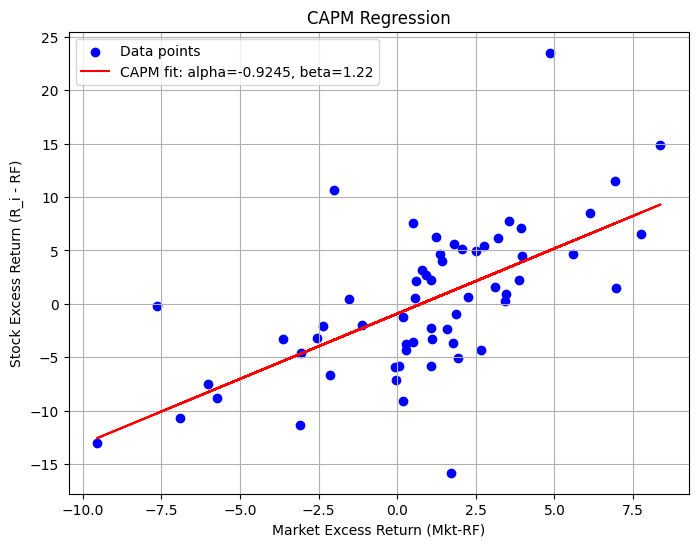

In [14]:
#CAPM Regression. 
X = sm.add_constant(factors['Mkt-RF'])  # independent variable
y = factors['Stock-RF']            # dependent variable

capm_model = sm.OLS(y, X).fit()

# Print results
print(capm_model.summary())

alpha = capm_model.params['const']
beta = capm_model.params['Mkt-RF']
X = factors['Mkt-RF']
# Regression line
y_pred = alpha + beta * X

# Plot
plt.figure(figsize=(8,6))
plt.scatter(X, y, color='blue', label='Data points')
plt.plot(X, y_pred, color='red', label=f'CAPM fit: alpha={alpha:.4f}, beta={beta:.2f}')
plt.xlabel('Market Excess Return (Mkt-RF)')
plt.ylabel('Stock Excess Return (R_i - RF)')
plt.title('CAPM Regression')
plt.legend()
plt.grid(True)
plt.show()

Now we will check the LINE conditions in python. <br>
L --> Linearity --> Residuals vs fit plot <br>
I --> Independence --> Durbin Watson Test --> Value close to 2 = good, <1.5 = positive autocorrelation. <br>
N --> Normality --> qq plot --> straight line approx <br>
E --> Equal Variance --> Breusch Pagan Test <br>
Both Durbin Watson, and Breusch Pagan Test assumes that the error terms are normally distributed. ( For DW test, its further assumed that the error terms have a mean of 0). One should note that these statistical tests are mainly for rejecting the null hypothesis (in this case our assumptions)<br>

In [15]:
# For testing linearity.
def linearity_check(model):
    residuals = capm_model.resid
    fitted = capm_model.fittedvalues
    plt.scatter(fitted, residuals, alpha=0.7)
    plt.axhline(y=0, color="red", linestyle="--")
    plt.xlabel("Fitted values")
    plt.ylabel("Residuals")
    plt.title("Residuals vs. Fitted")
    plt.show()

# For testing independence
def independence_check(model):
    from statsmodels.stats.stattools import durbin_watson
    n=model.nobs
    residuals=model.resid
    dw_stat = durbin_watson(residuals)
    rho_hat = 1 - dw_stat/2
    print(f"Durbin-Watson statistic: {dw_stat:.3f}")
    print(f"Lag-1 autocorrelation (rho): {rho_hat:.3f}")
""" The actual DW test also has the bounds d_L and d_U which are computed. However we do not pursue this at the moment for the sake of simplicity"""

# For normality 
def normal_check(model):
    sns.histplot(model.resid, kde=True)
    plt.title("Residuals Histogram")
    plt.show()
    sm.qqplot(model.resid,line='q')
    plt.title("Q–Q Plot")
    plt.show()

# For Equal variance 
def homoscedasticity_check(model):
    from statsmodels.stats.diagnostic import het_breuschpagan
    residuals=model.resid;
    bp_test = het_breuschpagan(residuals, model.model.exog)
    bp_stat, bp_pvalue = bp_test[0], bp_test[1]
    df = len(model.params)-1  # exclude intercept
    # CI for BP statistic under chi-square(df)
    print(f"Breusch–Pagan statistic: {bp_stat:.3f}, p-value: {bp_pvalue:.3f}")

def LINE_conditions_check(model):
    linearity_check(model);
    normal_check(model);
    independence_check(model);
    homoscedasticity_check(model);

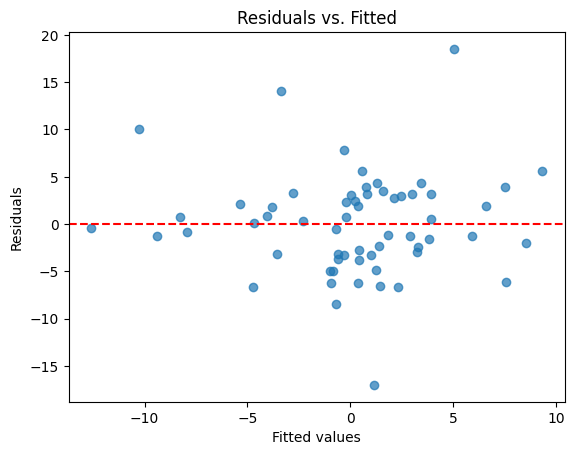

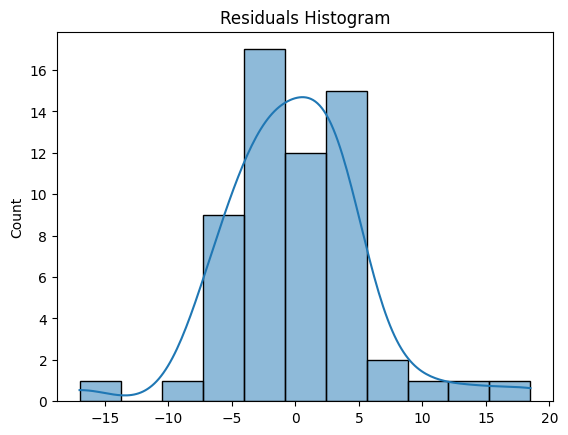

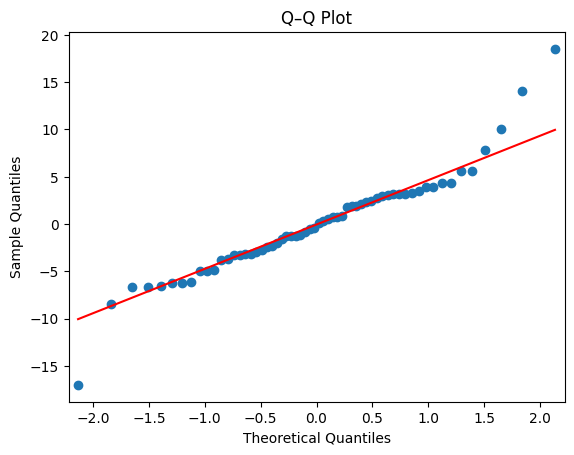

Durbin-Watson statistic: 1.919
Lag-1 autocorrelation (rho): 0.040
Breusch–Pagan statistic: 0.174, p-value: 0.677


In [16]:
LINE_conditions_check(capm_model)

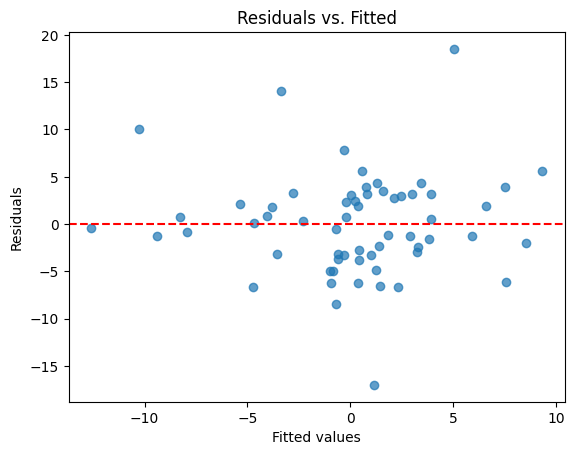

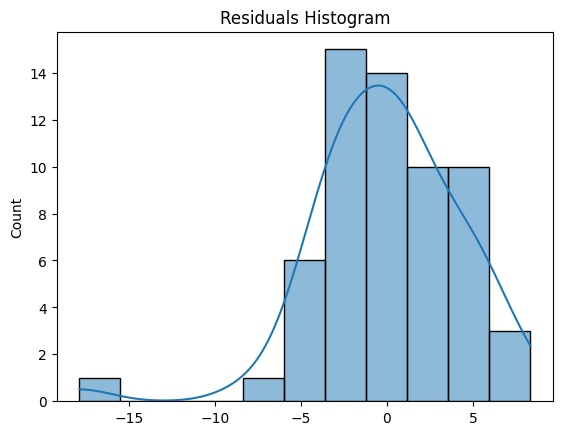

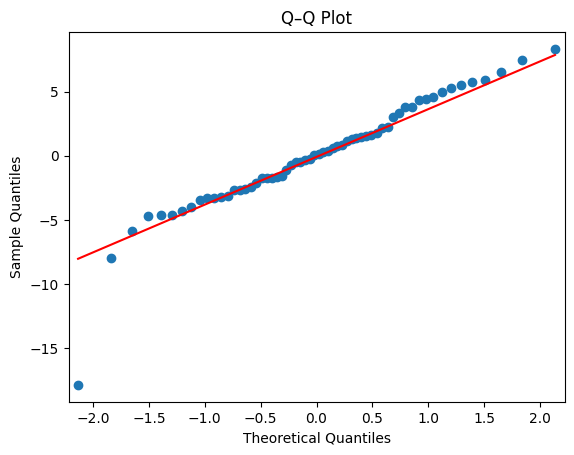

Durbin-Watson statistic: 2.099
Lag-1 autocorrelation (rho): -0.050
Breusch–Pagan statistic: 2.115, p-value: 0.549


In [17]:
# Will shift to FAMA now. The Independent variables are
X = factors[['Mkt-RF', 'SMB', 'HML']]
X = sm.add_constant(X)  # adds alpha

# Dependent variable
y = factors['Stock-RF']

# Run Fama-French regression
ff_model_ols = sm.OLS(y, X).fit() #OLS
LINE_conditions_check(ff_model_ols)

Conclusion : Looking at the histogram, it is evident that the normality condition is not satisfied. Although Durbin Watson and Berusch Pagan Test provide values within the given scope, we cannot confirm as these two tests heavily depend on the normality. It would be interesting to see if the normality condition holds true for other time periods.